# Phân tích và tiền xử lý dữ liệu

Thực hiện phân tích dữ liệu khám phá (EDA), trực quan hoá và tiền xử lý dữ liệu cho bài toán phát hiện bất thường trong mạng.

## 1. Import thư viện 

In [165]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')

print("Thư viện đã import thành công!")

Thư viện đã import thành công!


## 2. Load dữ liệu và khám phá tổng quan

In [166]:
# Load dữ liệu
file_path = r"data/raw/UNSW_NB15_training-set.csv"
df = pd.read_csv(file_path)

print("Kích thước dữ liệu:", df.shape)
print("Các cột dữ liệu:", list(df.columns))
df.head()

Kích thước dữ liệu: (175341, 45)
Các cột dữ liệu: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [167]:
print("Tổng quan cấu trúc:")
df.info()

Tổng quan cấu trúc:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-n

In [168]:
print("Số lượng Normal(0) và Attack(1):")
print(df['label'].value_counts())

Số lượng Normal(0) và Attack(1):
label
1    119341
0     56000
Name: count, dtype: int64


In [169]:
print("Số Missing values của các cột:")
print(df.isnull().sum())

Số Missing values của các cột:
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_

In [170]:
df.describe(include='all')

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,175341.000000,175341.000000,175341,175341,175341,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341,175341.000000
unique,NaN,NaN,133,13,9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,INT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,79946,94168,82275,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56000,NaN
mean,87671.000000,1.359389,NaN,NaN,NaN,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,...,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,NaN,0.680622
std,50616.731112,6.480249,NaN,NaN,NaN,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,...,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,NaN,0.466237
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,43836.000000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,...,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,NaN,0.000000
50%,87671.000000,0.001582,NaN,NaN,NaN,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,...,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,NaN,1.000000
75%,131506.000000,0.668069,NaN,NaN,NaN,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,...,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,NaN,1.000000


## 3. Trực quan hoá dữ liệu ban đầu 

Saved: results/class_distribution_pie.png


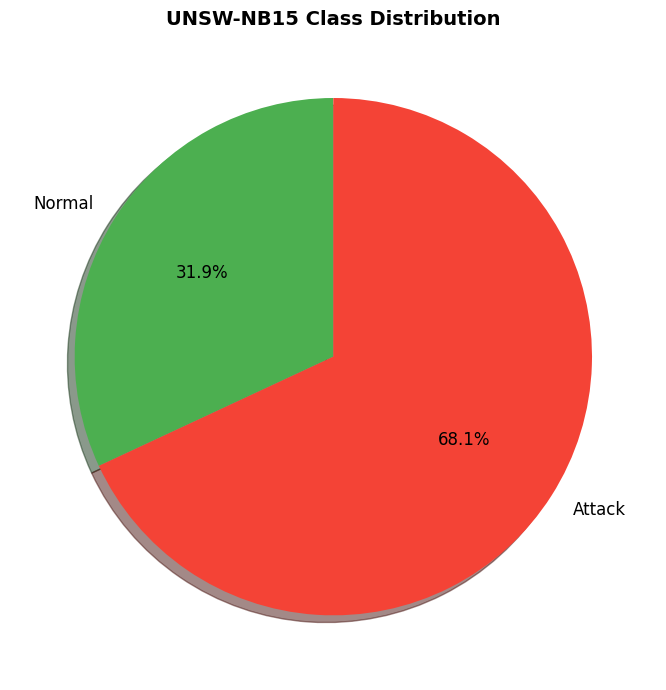

In [171]:
import os
import matplotlib.pyplot as plt

classes = df['label'].value_counts().sort_index()

labels = ['Normal', 'Attack']
colors = ['#4CAF50', '#F44336'] 

plt.figure(figsize=(7, 7))
plt.pie(
    classes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True,
    textprops={'fontsize': 12}
)

plt.title('UNSW-NB15 Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

# Lưu ảnh vào results/
os.makedirs("results", exist_ok=True)
out_path = "results/class_distribution_pie.png"
plt.savefig(out_path, dpi=350, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()


Saved: results\corr_spearman_full.png


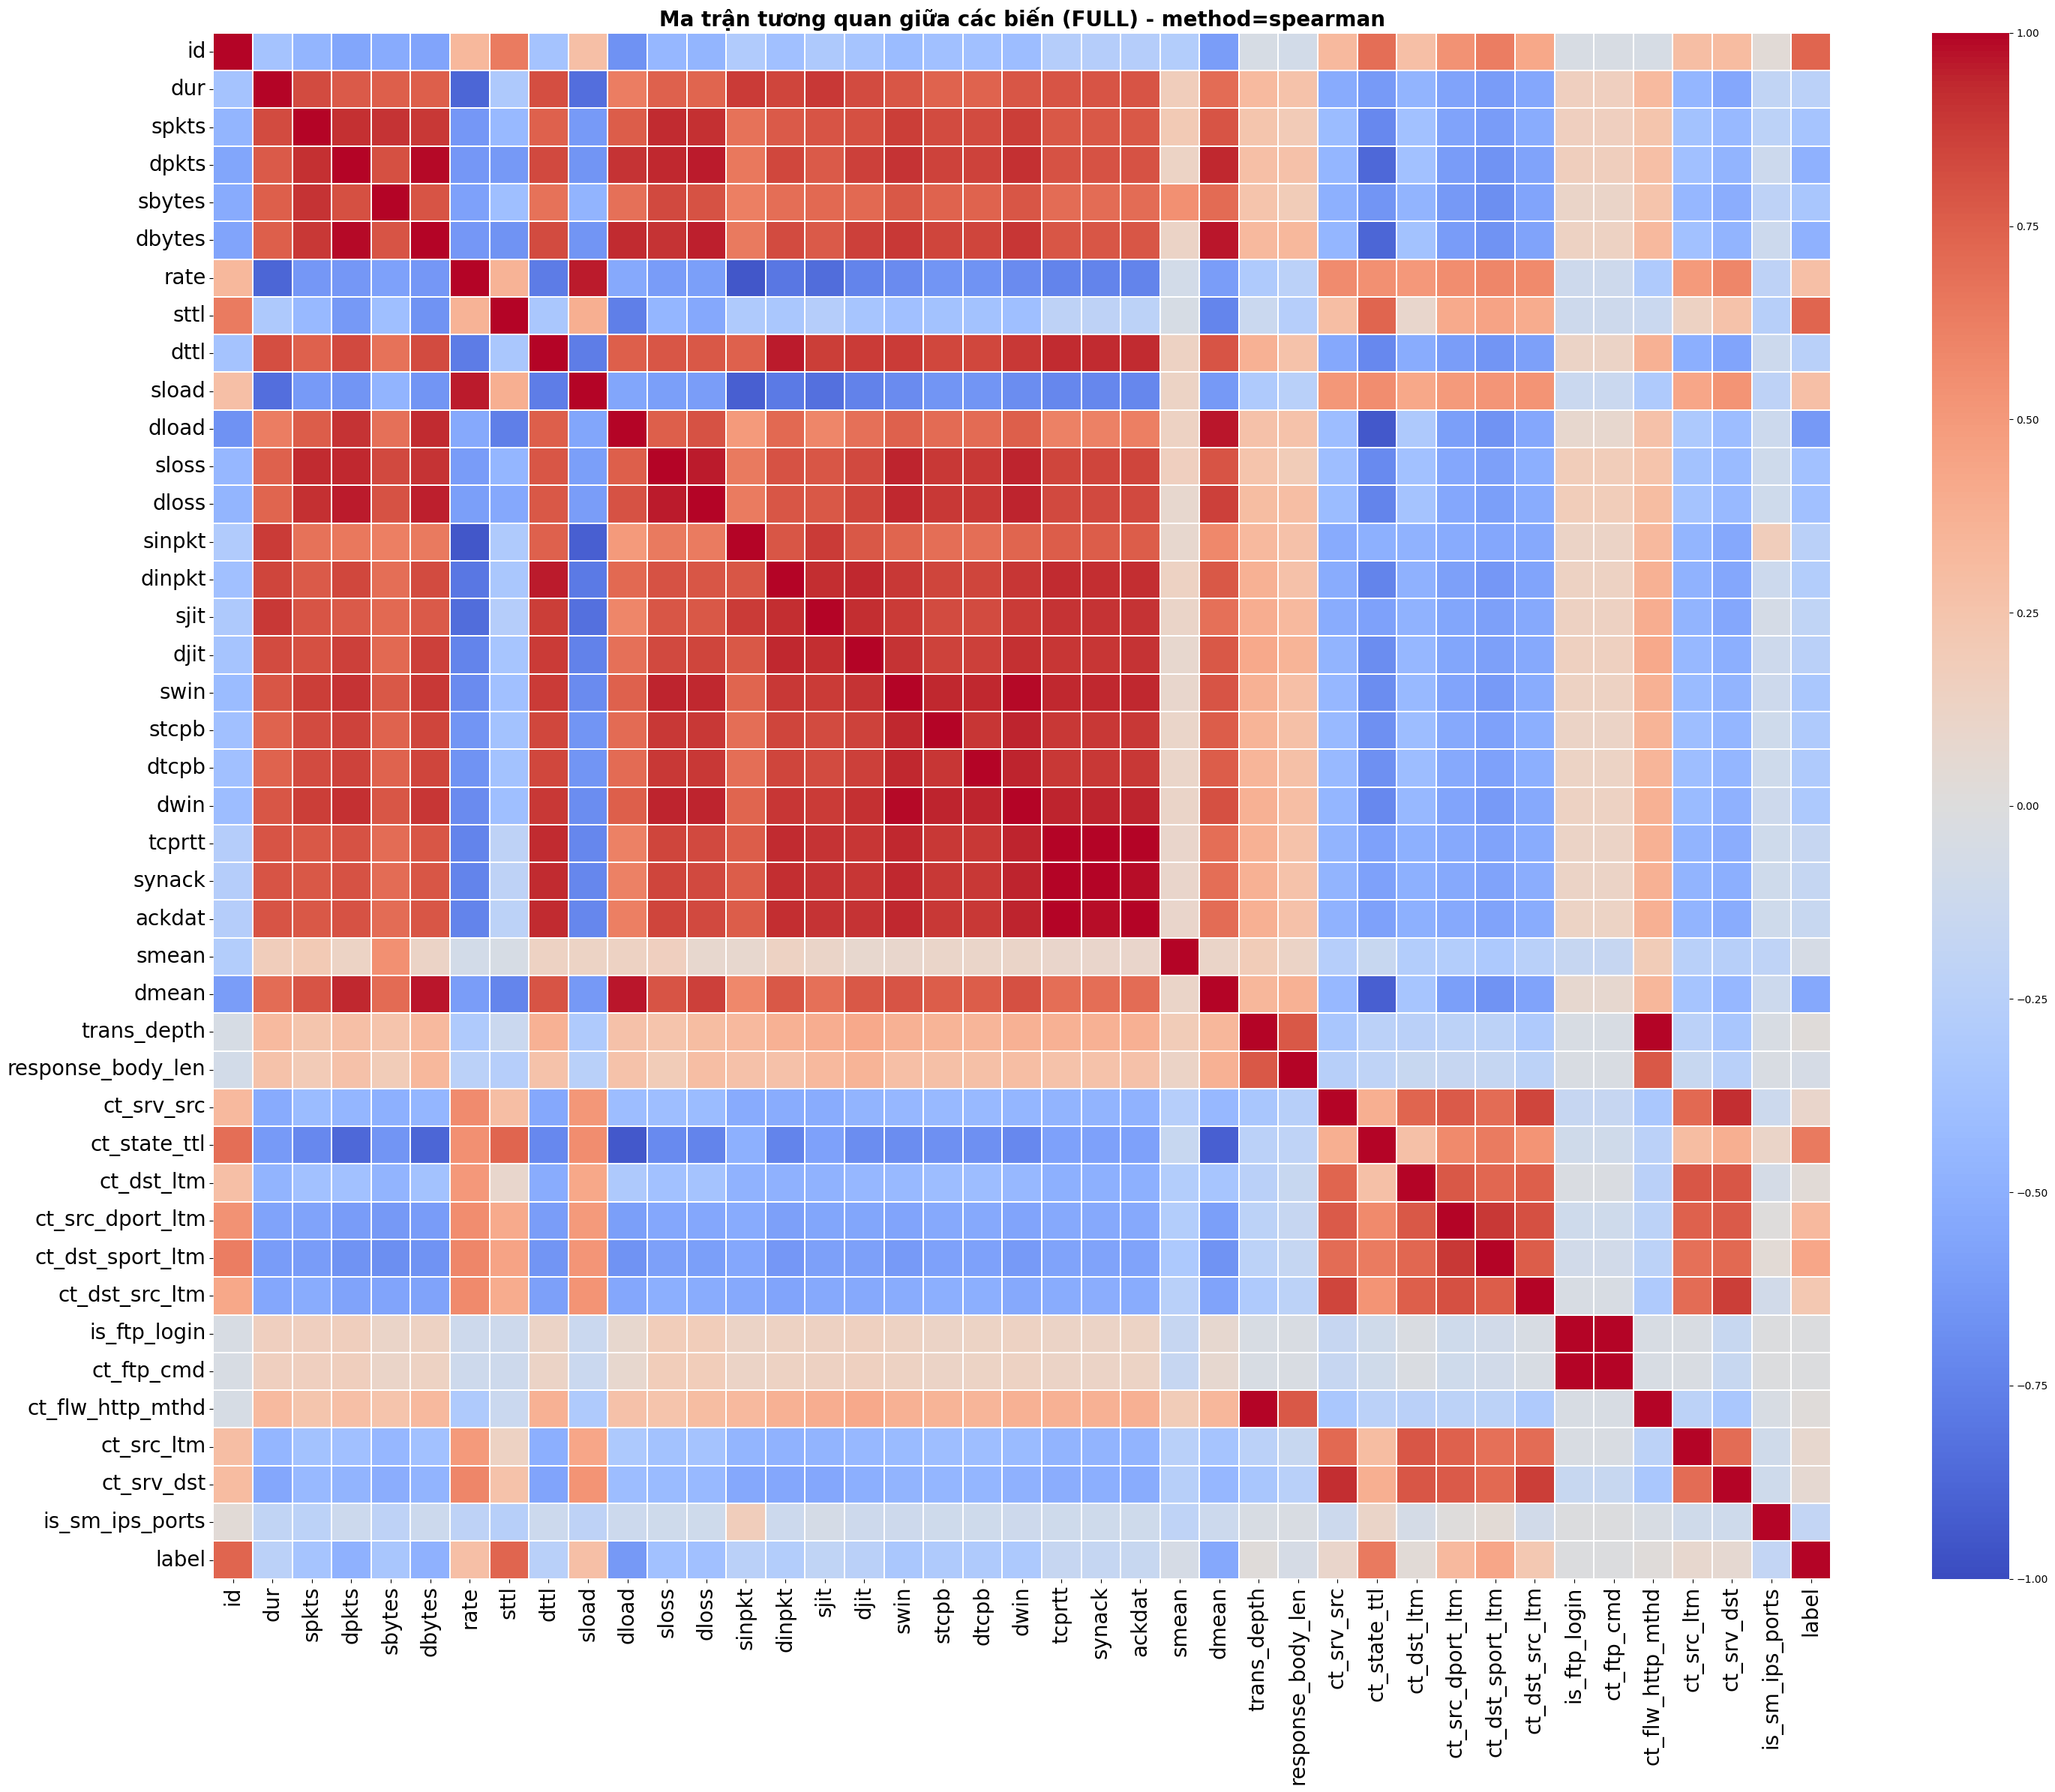

In [172]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def plot_corr_heatmap_full(df, method="spearman", figsize=(28, 22), title=None, annot=False,
                           save=True, out_dir="results", filename=None, dpi=300):
    """
    Vẽ ma trận tương quan full cho tất cả cột numeric.
    """
    num_df = df.select_dtypes(include=[np.number]).copy()
    corr = num_df.corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        linewidths=0.2,
        cbar=True,
        annot=annot,
        fmt=".2f" if annot else None
    )

    if title is None:
        title = f"Ma trận tương quan giữa các biến (FULL) - method={method}"
    plt.title(title, fontsize=20, fontweight="bold")

    plt.xticks(rotation=90, fontsize=20)
    plt.yticks(rotation=0, fontsize=20)

    plt.tight_layout()

    if save:
        os.makedirs(out_dir, exist_ok=True)
        if filename is None:
            filename = f"corr_full_{method}.png"
        out_path = os.path.join(out_dir, filename)
        plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()

plot_corr_heatmap_full(df, method="spearman", figsize=(30, 24), annot=False,
                       save=True, out_dir="results", filename="corr_spearman_full.png", dpi=400)


## 4. Tiền xử lý dữ liệu

### 1. Drop columns

In [173]:
drop_columns = [
    "attack_cat", "id",
    "response_body_len", "ct_flw_http_mthd",
    "trans_depth", "dwin", "ct_ftp_cmd", "is_ftp_login",
]

for col in drop_columns:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

In [174]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,0,1,1,1,1,1,1,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,43,1,1,1,1,2,1,6,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,7,1,2,1,1,3,2,6,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,1,2,1,1,3,2,1,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,43,1,2,2,1,40,2,39,0,0


In [175]:
def drop_high_corr_only(df, target="label", threshold=0.95, method="spearman", verbose=True):
    """
    Drop các feature numeric có tương quan cao với nhau (|corr| > threshold).
    Quy tắc: trong 1 cặp (a,b) corr cao -> drop feature nào có |corr với label| thấp hơn.
    """
    if target not in df.columns:
        raise ValueError(f"Không thấy cột target '{target}' trong df!")

    # chỉ lấy numeric (bao gồm label)
    num_df = df.select_dtypes(include=[np.number]).copy()
    if target not in num_df.columns:
        raise ValueError(f"'{target}' không nằm trong các cột numeric (kiểm tra dtype của label).")

    # feature candidates: mọi numeric trừ target
    feature_cols = [c for c in num_df.columns if c != target]

    # corr giữa feature-feature
    corr_mat = num_df[feature_cols].corr(method=method).abs()
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

    # corr của feature với label để quyết định giữ/bỏ
    corr_to_target = num_df.corr(method=method)[target].abs()

    # danh sách cặp corr cao
    pairs = []
    for col in upper.columns:
        high = upper[col][upper[col] > threshold]
        for row, val in high.items():
            pairs.append((row, col, float(val)))

    if verbose:
        print(f"Số cặp feature có |corr| > {threshold}: {len(pairs)}")

    # quyết định drop
    to_drop = set()
    for a, b, val in sorted(pairs, key=lambda x: x[2], reverse=True):
        if a in to_drop or b in to_drop:
            continue

        ca = float(corr_to_target.get(a, 0.0))
        cb = float(corr_to_target.get(b, 0.0))

        # drop cái ít liên quan label hơn
        drop = a if ca < cb else b
        to_drop.add(drop)

    drop_list = sorted(to_drop)

    if verbose:
        print(f"Số feature sẽ drop: {len(drop_list)}")
        print("Các cột bị drop :", drop_list[:10])

    df_reduced = df.drop(columns=drop_list, errors="ignore")
    return df_reduced, drop_list, pairs

df_reduced, dropped_cols, high_corr_pairs = drop_high_corr_only(
    df,                 
    target="label",
    threshold=0.95,
    method="spearman",
    verbose=True
)

print("Shape trước:", df.shape)
df = df_reduced
print("Shape sau:", df.shape)


Số cặp feature có |corr| > 0.95: 11
Số feature sẽ drop: 8
Các cột bị drop : ['ackdat', 'dbytes', 'dmean', 'dpkts', 'dttl', 'rate', 'sloss', 'tcprtt']
Shape trước: (175341, 37)
Shape sau: (175341, 29)


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   dur               175341 non-null  float64
 1   proto             175341 non-null  object 
 2   service           175341 non-null  object 
 3   state             175341 non-null  object 
 4   spkts             175341 non-null  int64  
 5   sbytes            175341 non-null  int64  
 6   sttl              175341 non-null  int64  
 7   sload             175341 non-null  float64
 8   dload             175341 non-null  float64
 9   dloss             175341 non-null  int64  
 10  sinpkt            175341 non-null  float64
 11  dinpkt            175341 non-null  float64
 12  sjit              175341 non-null  float64
 13  djit              175341 non-null  float64
 14  swin              175341 non-null  int64  
 15  stcpb             175341 non-null  int64  
 16  dtcpb             17

### 2. Apply Clamping

In [177]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,sbytes,sttl,sload,dload,dloss,sinpkt,dinpkt,sjit,...,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,8.844844e+03,179.546997,7.345403e+07,6.712056e+05,6.948010,985.976864,88.216296,4.976254e+03,...,9.306437,1.304179,6.193936,5.383538,4.206255,8.729881,6.955789,9.100758,0.015752,0.680622
std,6.480249,136.887597,1.747656e+05,102.940011,1.883574e+08,2.421312e+06,52.732999,7242.245841,987.093195,4.496585e+04,...,10.704331,0.954406,8.052476,8.047104,5.783585,10.956186,8.321493,10.756952,0.124516,0.466237
min,0.000000,1.000000,2.800000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,1.140000e+02,62.000000,1.305334e+04,0.000000e+00,0.000000,0.008000,0.000000,0.000000e+00,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,0.000000,0.000000
50%,0.001582,2.000000,4.300000e+02,254.000000,8.796748e+05,1.447023e+03,0.000000,0.279733,0.006000,0.000000e+00,...,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,3.000000,4.000000,0.000000,1.000000
75%,0.668069,12.000000,1.418000e+03,254.000000,8.888889e+07,2.784487e+04,2.000000,55.156896,51.053000,2.513295e+03,...,12.000000,2.000000,7.000000,5.000000,3.000000,12.000000,9.000000,12.000000,0.000000,1.000000
max,59.999989,9616.000000,1.296523e+07,255.000000,5.988000e+09,2.242273e+07,5484.000000,84371.496000,56716.824000,1.460480e+06,...,63.000000,6.000000,51.000000,51.000000,46.000000,65.000000,60.000000,62.000000,1.000000,1.000000


In [178]:
DEBUG =0

for feature in df_numeric.columns:
    if DEBUG == 1:
        print(feature)
        print('max = '+str(df_numeric[feature].max()))
        print('75th = '+str(df_numeric[feature].quantile(0.95)))
        print('median = '+str(df_numeric[feature].median()))
        print(df_numeric[feature].max()>10*df_numeric[feature].median())
        print('----------------------------------------------------')
    if df_numeric[feature].max()>10*df_numeric[feature].median() and df_numeric[feature].max()>10 :
        df[feature] = np.where(df[feature]<df[feature].quantile(0.95), df[feature], df[feature].quantile(0.95))

df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,sbytes,sttl,sload,dload,dloss,sinpkt,dinpkt,sjit,...,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,0.467065,12.617323,1697.289989,179.546997,5.327025e+07,3.654831e+05,3.029765,37.149345,29.464980,1682.831478,...,9.084264,1.304179,5.793283,4.903263,4.145226,8.505609,6.624788,8.882760,0.015752,0.680622
std,0.816099,17.574046,3266.805316,102.940011,7.771134e+07,1.011632e+06,6.159003,64.856251,49.122669,2824.169851,...,10.088830,0.954406,6.791916,6.544978,5.589185,10.339146,7.307812,10.154088,0.124516,0.466237
min,0.000000,1.000000,28.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,114.000000,62.000000,1.305334e+04,0.000000e+00,0.000000,0.008000,0.000000,0.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,0.000000,0.000000
50%,0.001582,2.000000,430.000000,254.000000,8.796748e+05,1.447023e+03,0.000000,0.279733,0.006000,0.000000,...,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,3.000000,4.000000,0.000000,1.000000
75%,0.668069,12.000000,1418.000000,254.000000,8.888889e+07,2.784487e+04,2.000000,55.156896,51.053000,2513.295019,...,12.000000,2.000000,7.000000,5.000000,3.000000,12.000000,9.000000,12.000000,0.000000,1.000000
max,3.079511,64.000000,13662.000000,255.000000,2.666667e+08,4.071050e+06,24.000000,245.212857,160.491672,9505.475298,...,33.000000,6.000000,24.000000,22.000000,17.000000,33.000000,26.000000,33.000000,1.000000,1.000000


### 3. Feature engineering

In [179]:
def create_count_df(col, data=None):
    df = pd.DataFrame(data[col].value_counts().reset_index().values, columns = [col, 'count'])
    df['percent'] = df['count'].values*100/data.shape[0]
    return df.sort_values(by='percent', ascending=False)

In [180]:
col = 'state'
create_count_df(col, df)

,state,count,percent
0,INT,82275,46.922853
1,FIN,77825,44.384941
2,CON,13152,7.500813
3,REQ,1991,1.135502
4,RST,83,0.047336
5,ECO,12,0.006844
6,PAR,1,0.00057
7,URN,1,0.00057
8,no,1,0.00057


In [181]:
col = 'service'
create_count_df(col, df)

,service,count,percent
0,-,94168,53.705636
1,dns,47294,26.972585
2,http,18724,10.678621
3,smtp,5058,2.884665
4,ftp-data,3995,2.278417
5,ftp,3428,1.955048
6,ssh,1302,0.742553
7,pop3,1105,0.630201
8,dhcp,94,0.05361
9,snmp,80,0.045625


In [182]:
col = 'proto'
create_count_df(col, df)

,proto,count,percent
0,tcp,79946,45.594584
1,udp,63283,36.091388
2,unas,12084,6.891714
3,arp,2859,1.630537
4,ospf,2595,1.479973
...,...,...,...
128,argus,98,0.055891
129,netblt,98,0.055891
130,igmp,18,0.010266
131,icmp,15,0.008555


In [183]:
X = df.drop(columns=["label"])
y = df["label"]
# Feature engineering
keep_state   = ["FIN","INT","CON","REQ","RST"]
keep_service = ["-","dns","http","smtp","ftp-data","ftp","ssh","pop3"]
keep_proto   = ["tcp","udp","arp","ospf","igmp_icmp_rtp"]

X.loc[~X["state"].isin(keep_state), "state"] = "others"
X.loc[~X["service"].isin(keep_service), "service"] = "others"
X.loc[X["proto"].isin(["igmp","icmp","rtp"]), "proto"] = "igmp_icmp_rtp"
X.loc[~X["proto"].isin(keep_proto), "proto"] = "others"

### 4. One-hot

In [184]:
# Onehot
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X_oh = pd.get_dummies(X, columns=cat_cols)
X_oh = X_oh.astype(np.float32)

# ghép label 
preprocess_df = X_oh.copy()
preprocess_df["label"] = y.values

In [185]:
preprocess_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 47 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dur                  175341 non-null  float32
 1   spkts                175341 non-null  float32
 2   sbytes               175341 non-null  float32
 3   sttl                 175341 non-null  float32
 4   sload                175341 non-null  float32
 5   dload                175341 non-null  float32
 6   dloss                175341 non-null  float32
 7   sinpkt               175341 non-null  float32
 8   dinpkt               175341 non-null  float32
 9   sjit                 175341 non-null  float32
 10  djit                 175341 non-null  float32
 11  swin                 175341 non-null  float32
 12  stcpb                175341 non-null  float32
 13  dtcpb                175341 non-null  float32
 14  synack               175341 non-null  float32
 15  smean            

In [186]:
preprocess_df.describe()

,dur,spkts,sbytes,sttl,sload,dload,dloss,sinpkt,dinpkt,sjit,...,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_RST,state_others,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,0.467065,12.617323,1697.289917,179.547012,5.327025e+07,3.654831e+05,3.029765,37.149342,29.464979,1682.831543,...,0.006302,0.028847,0.007426,0.075008,0.443849,0.469229,0.011355,0.000473,0.000086,0.680622
std,0.816099,17.574047,3266.805420,102.940010,7.771134e+07,1.011632e+06,6.159003,64.856255,49.122669,2824.169922,...,0.079135,0.167376,0.085851,0.263405,0.496839,0.499054,0.105953,0.021752,0.009249,0.466237
min,0.000000,1.000000,28.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,114.000000,62.000000,1.305334e+04,0.000000e+00,0.000000,0.008000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,430.000000,254.000000,8.796748e+05,1.447023e+03,0.000000,0.279733,0.006000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,1418.000000,254.000000,8.888889e+07,2.784487e+04,2.000000,55.156895,51.053001,2513.294922,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,3.079511,64.000000,13662.000000,255.000000,2.666667e+08,4.071050e+06,24.000000,245.212860,160.491669,9505.475586,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [187]:
preprocess_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 47 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dur                  175341 non-null  float32
 1   spkts                175341 non-null  float32
 2   sbytes               175341 non-null  float32
 3   sttl                 175341 non-null  float32
 4   sload                175341 non-null  float32
 5   dload                175341 non-null  float32
 6   dloss                175341 non-null  float32
 7   sinpkt               175341 non-null  float32
 8   dinpkt               175341 non-null  float32
 9   sjit                 175341 non-null  float32
 10  djit                 175341 non-null  float32
 11  swin                 175341 non-null  float32
 12  stcpb                175341 non-null  float32
 13  dtcpb                175341 non-null  float32
 14  synack               175341 non-null  float32
 15  smean            

In [188]:
preprocess_df.to_csv("data/preprocess/preprocess.csv", index=False, encoding="utf-8")